# Convex optimization

1. **문제의 수학적 형태**: LP, QP, SOCP, SDP, exponential-cone model  
2. **CVXPY 모델링 패턴**: `Variable`, `Parameter`, `Problem`, `solve`, DCP rules  
3. **기하학적 해석**: feasible set, supporting hyperplane, margin, efficient frontier  
4. **응용**: portfolio, control, robust optimization, logistic regression

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "svg"

import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import cvxpy as cp

from matplotlib.patches import Circle
from scipy.spatial import ConvexHull

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(12)

mpl.rcParams["figure.figsize"] = (6, 4)
mpl.rcParams["font.size"] = 12
mpl.rcParams["axes.grid"] = True

print("CVXPY version:", cp.__version__)
print("Installed solvers:", cp.installed_solvers())


CVXPY version: 1.8.2
Installed solvers: ['CLARABEL', 'HIGHS', 'OSQP', 'SCIPY', 'SCS']


In [2]:
def solve_or_raise(problem, solver=None, **kwargs):
    value = problem.solve(solver=solver, **kwargs)
    if problem.status not in ("optimal", "optimal_inaccurate"):
        raise RuntimeError(f"Problem status: {problem.status}")
    return value

def make_grid(xlim, ylim, n=400):
    x = np.linspace(xlim[0], xlim[1], n)
    y = np.linspace(ylim[0], ylim[1], n)
    return np.meshgrid(x, y)

def gaussian_pdf(x, mean, var):
    std = np.sqrt(max(var, 1e-8))
    return np.exp(-0.5 * ((x - mean) / std) ** 2) / (std * np.sqrt(2 * np.pi))

def halfspace_mask(A, b, xlim, ylim, n=400):
    X, Y = make_grid(xlim, ylim, n=n)
    P = np.stack([X, Y], axis=-1)
    values = P @ A.T
    mask = np.all(values <= b + 1e-9, axis=-1)
    return X, Y, mask

def plot_line(ax, a, rhs, xlim, label=None, linestyle="-"):
    xs = np.linspace(xlim[0], xlim[1], 400)
    if abs(a[1]) > 1e-10:
        ys = (rhs - a[0] * xs) / a[1]
        ax.plot(xs, ys, linestyle=linestyle, label=label)
    else:
        ax.axvline(rhs / a[0], linestyle=linestyle, label=label)

def margin_lines(w, b, xlim):
    xs = np.linspace(xlim[0], xlim[1], 400)
    decision = -(w[0] * xs + b) / w[1]
    plus = -(w[0] * xs + b - 1) / w[1]
    minus = -(w[0] * xs + b + 1) / w[1]
    return xs, decision, plus, minus


## Part 0. convex optimization


### 1. 우리가 풀고 싶은 것은 “최적화 문제”다
일반적인 최적화 문제는
$
\min_x f(x) \quad \text{subject to} \quad x \in \mathcal{C}
$
꼴입니다.  
여기서 중요한 질문은 두 가지입니다.

- **목적함수** \(f\)가 convex인가?
- **feasible set** \(\mathcal{C}\)가 convex인가?

이 두 가지가 모두 맞으면 local minimum과 global minimum이 일치하고, 수치적으로도 훨씬 안정적입니다.

### 2. 볼록최적화는 “안전한 최적화”다
convex optimization에서는 다음이 동시에 성립합니다.

- 나쁜 local minimum에 덜 갇힌다
- optimality condition이 깔끔하다
- duality와 sensitivity analysis가 잘 작동한다
- 모델링 언어(CVXPY)가 자동으로 convexity를 검사할 수 있다

### 3. 관점
- **이 문제가 어느 클래스(LP/QP/SOCP/SDP)에 속하는지**
- **CVXPY에서 어떻게 쓰는지**
- **해의 기하학적 의미가 무엇인지**
- **응용에서 왜 이 구조가 반복되는지**

를 다룰예정.

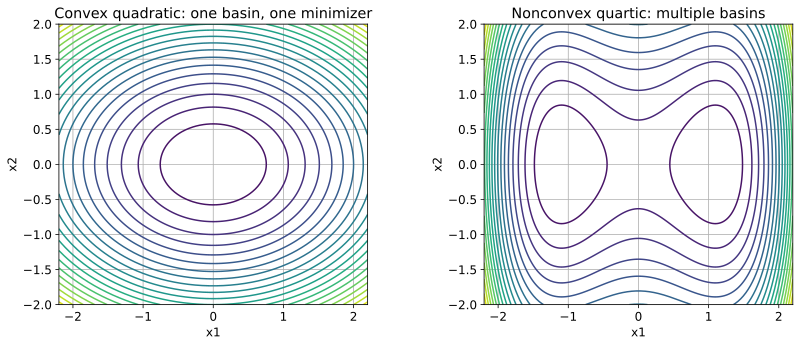

In [3]:
X, Y = make_grid((-2.2, 2.2), (-2.0, 2.0), n=350)

Z_convex = 0.7 * X**2 + 1.2 * Y**2
Z_nonconvex = 0.25 * (X**2 - 1.2)**2 + 0.35 * Y**2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
cs = ax.contour(X, Y, Z_convex, levels=20)
ax.set_title("Convex quadratic: one basin, one minimizer")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_aspect("equal")

ax = axes[1]
cs = ax.contour(X, Y, Z_nonconvex, levels=20)
ax.set_title("Nonconvex quartic: multiple basins")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()



- 왼쪽의 convex quadratic은 contour가 “한 점을 향해” 모입니다.
- 오른쪽의 nonconvex quartic은 basin이 여러 개라서 시작점에 따라 전혀 다른 곳으로 갈 수 있습니다.

### 질문
1. 왜 quadratic form $(x^\top Qx)$에서 $Q\succeq 0$가 중요한가?
2. feasible set이 convex인데 목적함수가 nonconvex이면 무슨 일이 생기는가?
3. 목적함수가 convex인데 제약집합이 nonconvex이면 왜 다시 어려워지는가?


## Part 1. CVXPY workflow와 DCP rules 

CVXPY는 단순한 “최적화 라이브러리”가 아니라,  
**disciplined convex programming (DCP)** 규칙에 따라 식이 convex한지 자동 검사하는 모델링 언어입니다.

### CVXPY의 기본 흐름
1. `Variable`, `Parameter`를 만든다
2. objective를 `Minimize(...)` 또는 `Maximize(...)`로 쓴다
3. constraints를 리스트로 적는다
4. `Problem(objective, constraints)`를 만든다
5. `solve()`를 호출한다

### 그런데 왜 DCP가 중요한가?
수학적으로는 같은 함수라도, CVXPY는 **원자(atom)** 와 **합성 규칙(composition rule)** 으로 convexity를 추론합니다.  
따라서 좋은 모델러는 “정답인 식”뿐 아니라 “파서가 이해하기 좋은 식”도 알아야 합니다.

이 파트에서는 두 가지를 확인합니다.

- 어떤 원자들이 convex / concave 인지
- 같은 뜻이라도 어떤 표기가 DCP-friendly한지


In [4]:
x = cp.Variable(3)

catalog = [
    ("cp.sum_squares(x)", cp.sum_squares(x)),
    ("cp.norm(x, 2)", cp.norm(x, 2)),
    ("cp.norm(x, 1)", cp.norm(x, 1)),
    ("cp.max(x)", cp.max(x)),
    ("cp.log_sum_exp(x)", cp.log_sum_exp(x)),
    ("cp.logistic(x[0])", cp.logistic(x[0])),
]

rows = []
for name, expr in catalog:
    rows.append(
        {
            "expression": name,
            "is_convex": expr.is_convex(),
            "is_concave": expr.is_concave(),
        }
    )

pd.DataFrame(rows)


,expression,is_convex,is_concave
0,cp.sum_squares(x),True,False
1,"cp.norm(x, 2)",True,False
2,"cp.norm(x, 1)",True,False
3,cp.max(x),True,False
4,cp.log_sum_exp(x),True,False
5,cp.logistic(x[0]),True,False


In [5]:
z = cp.Variable(2)
r = cp.Variable(nonneg=True)
t = cp.Variable(nonneg=True)

good_norm_problem = cp.Problem(cp.Minimize(cp.norm(z, 2)))
bad_norm_problem = cp.Problem(cp.Minimize(cp.sqrt(cp.sum_squares(z))))

good_circle_problem = cp.Problem(cp.Minimize(r), [cp.norm(z, 2) <= r])
bad_circle_problem = cp.Problem(cp.Minimize(t), [cp.norm(z, 2) <= cp.sqrt(t)])

print("good_norm_problem.is_dcp() =", good_norm_problem.is_dcp())
print("bad_norm_problem.is_dcp()  =", bad_norm_problem.is_dcp())
print()
print("good_circle_problem.is_dcp() =", good_circle_problem.is_dcp())
print("bad_circle_problem.is_dcp()  =", bad_circle_problem.is_dcp())


good_norm_problem.is_dcp() = True
bad_norm_problem.is_dcp()  = False

good_circle_problem.is_dcp() = True
bad_circle_problem.is_dcp()  = True


### 이 결과는 CVXPY를 배울 때 매우 중요!!!

### 왜 이런 차이가 생기나?
- `cp.norm(z, 2)`는 CVXPY가 **직접 알고 있는 convex 구조**입니다.
- `cp.sqrt(cp.sum_squares(z))`는 사람 눈에는 norm과 같아 보여도,  
  CVXPY는 `sqrt(convex)` 합성을 보고 **일반적인 DCP 규칙으로는 보수적으로 거절**합니다.

### 실전에서의 규칙
- norm은 `cp.norm(...)`
- quadratic은 `cp.quad_form(...)` 또는 `cp.sum_squares(...)`
- log-sum-exp는 `cp.log_sum_exp(...)`
- logistic loss는 `cp.logistic(...)`

처럼 **표준 형태**으로 쓰는 습관이 좋습니다.

### 질문 (생각해볼점)
1. “수학적으로 동치”와 “DCP 관점에서 좋은 모델”은 왜 다른가?
2. `cp.norm(x, 2) <= r`가 SOCP라는 것을 기하학적으로 어떻게 설명할 수 있을까?
3. 앞으로 나올 예제 중 어떤 atom이 반복될지 예상해볼 수 있는가?


## Part 2. LP: transportation, linear-fractional transform, Chebyshev center

기본적인 convex optimization 클래스인 **선형계획법(LP)** 

### LP의 핵심
$
\min_x c^\top x \quad \text{subject to} \quad Ax \le b,\; Ex = f
$

처럼 목적함수와 제약이 모두 affine인 문제가 LP입니다.

LP는 다음 이유로 중요합니다.

- 모델링이 쉽다
- duality가 특히 깔끔하다
- 많은 문제를 변수 확장으로 LP에 넣을 수 있다
- 실제 산업 응용(transport, allocation, scheduling)의 출발점이다

이 파트에서는 세 가지 대표 예제를 봅니다.

1. **optimal transportation**  
2. **linear-fractional programming의 LP 변환**  
3. **Chebyshev center**


### 2-1. Optimal transportation problem

생산자 $i=1,\dots,m$와 소비자 $j=1,\dots,n$가 있을 때,  
$x_{ij}$를 “생산자 $i$에서 소비자 $j$로 보내는 양”이라고 두면

$
\min \sum_{i=1}^m \sum_{j=1}^n c_{ij} x_{ij}
$

subject to
$
\sum_j x_{ij} \le s_i, \qquad
\sum_i x_{ij} \ge d_j, \qquad
x_{ij} \ge 0
$
가 됩니다.

여기서 중요한 점은 **의사결정변수는 행렬**일 수 있다는 것입니다.  
CVXPY의 `Variable((m, n), nonneg=True)`는 이런 모델에 아주 자연스럽습니다.


Optimal transportation cost: 320.0

Shipment matrix:
[[ 0. 20.  0.  0.]
 [ 0.  0.  5. 25.]
 [30.  0. 20.  0.]]

Row sums (used supply): [20. 30. 50.]
Column sums (served demand): [30. 20. 25. 25.]


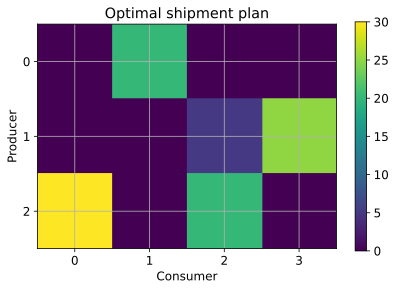

In [6]:
# Transportation LP
m, n = 3, 4
supply = np.array([20, 30, 50], dtype=float)
demand = np.array([30, 20, 25, 25], dtype=float)
cost = np.array(
    [
        [8, 6, 10, 9],
        [9, 7, 4, 2],
        [3, 4, 2, 7],
    ],
    dtype=float,
)

x = cp.Variable((m, n), nonneg=True)
transport_problem = cp.Problem(
    cp.Minimize(cp.sum(cp.multiply(cost, x))),
    [
        cp.sum(x, axis=1) <= supply,
        cp.sum(x, axis=0) >= demand,
    ],
)
solve_or_raise(transport_problem, solver=cp.HIGHS)

print("Optimal transportation cost:", transport_problem.value)
print()
print("Shipment matrix:")
print(np.round(x.value, 3))
print()
print("Row sums (used supply):", np.round(np.sum(x.value, axis=1), 3))
print("Column sums (served demand):", np.round(np.sum(x.value, axis=0), 3))

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(x.value)
ax.set_title("Optimal shipment plan")
ax.set_xlabel("Consumer")
ax.set_ylabel("Producer")
ax.set_xticks(range(n))
ax.set_yticks(range(m))
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


### 2-2. Linear-fractional programming은 왜 LP로 바뀌는가? (Convex set에서 강의한내용 상기)

비율형 목적함수

$
\max_x \frac{c^\top x + d}{e^\top x + f}
$

는 겉보기에는 선형이 아닙니다.  
하지만 분모가 양수라는 조건 아래에서

$
t = \frac{1}{e^\top x + f}, \qquad y = tx
$

를 두면 LP로 바뀝니다.

핵심은 **분수 최적화 문제를 변수 치환으로 선형화**한다는 것입니다.  
이 아이디어는 이후의 perspective transform, homogenization과도 연결됩니다.


In [7]:
# Linear-fractional program transformed to an LP
A = np.array([[1, 2], [3, 1]], dtype=float)
b = np.array([8, 9], dtype=float)
c = np.array([3, 4], dtype=float)
d = 5.0
e = np.array([2, 1], dtype=float)
f = 6.0

y = cp.Variable(2, nonneg=True)
t = cp.Variable(nonneg=True)

lfp_problem = cp.Problem(
    cp.Maximize(c @ y + d * t),
    [
        A @ y <= b * t,
        e @ y + f * t == 1,
    ],
)
solve_or_raise(lfp_problem, solver=cp.HIGHS)

x_recovered = y.value / t.value
ratio_value = (c @ x_recovered + d) / (e @ x_recovered + f)

print("Recovered x:", np.round(x_recovered, 4))
print("Recovered objective value:", np.round(ratio_value, 6))
print("t value:", np.round(t.value, 6))


Recovered x: [0. 4.]
Recovered objective value: 2.1
t value: 0.1


### 2-3. Chebyshev center

Chebyshev center는 주어진 polytope 안에 들어가는 **가장 큰 Euclidean ball의 중심**입니다.  
기하학적으로는 “feasible region 한가운데서 가장 안전한 점”에 가깝습니다.

만약 polytope가

$
a_i^\top x \le b_i,\qquad i=1,\dots,m
$

로 주어졌다면, 반지름 \(r\)인 공이 내부에 들어가려면

$
a_i^\top x + \|a_i\|_2 r \le b_i
$

가 필요합니다.  
즉, distance-to-hyperplane 공식을 그대로 제약으로 넣으면 됩니다.


Chebyshev center: [ 0.1687 -0.0687]
Chebyshev radius: 1.0313


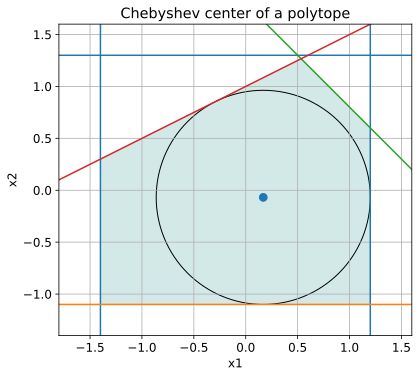

In [8]:
# Chebyshev center of a polytope
A = np.array(
    [
        [1.0, 0.0],
        [-1.0, 0.0],
        [0.0, 1.0],
        [0.0, -1.0],
        [1.0, 1.0],
        [-1.0, 2.0],
    ]
)
b = np.array([1.2, 1.4, 1.3, 1.1, 1.8, 2.0])

center = cp.Variable(2)
radius = cp.Variable(nonneg=True)

cheb_problem = cp.Problem(
    cp.Maximize(radius),
    [A @ center + np.linalg.norm(A, axis=1) * radius <= b],
)
solve_or_raise(cheb_problem, solver=cp.CLARABEL)

print("Chebyshev center:", np.round(center.value, 4))
print("Chebyshev radius:", np.round(radius.value, 4))

X, Y, mask = halfspace_mask(A, b, (-1.8, 1.6), (-1.4, 1.6), n=500)

fig, ax = plt.subplots(figsize=(6, 6))
ax.contourf(X, Y, mask.astype(float), levels=[0.5, 1.5], alpha=0.2)
for i in range(A.shape[0]):
    plot_line(ax, A[i], b[i], (-1.8, 1.6))
circle = Circle(center.value, radius.value, fill=False)
ax.add_patch(circle)
ax.scatter(center.value[0], center.value[1], s=60)
ax.set_title("Chebyshev center of a polytope")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_xlim(-1.8, 1.6)
ax.set_ylim(-1.4, 1.6)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


여기서 중요한 관찰은 다음입니다.

- 선형부등식으로 정의된 polytope 안에
- Euclidean ball이 들어가도록 하려면
- 각 면까지의 거리를 제약으로 써야 한다

즉, **geometry가 곧 modeling**입니다.

### 질문
1. transportation 문제에서 dual variable은 어떤 경제적 의미를 가질까?
2. linear-fractional transform에서 왜 \(t \ge 0\)가 중요한가?
3. Chebyshev center와 analytic center는 어떻게 다를까?


## Part 3. Quadratic optimization: Lasso와 max-margin SVM 

목적함수에 quadratic이 들어가는 문제들

- quadratic objective는 데이터 fitting이나 risk 측정에서 매우 자주 나온다
- norm 제약이나 margin 제약과 결합하면 강력한 통계/머신러닝 모델이 된다

대표 예제는

1. **Lasso**: sparse recovery와 feature selection  
2. **Hard-margin SVM**: separating hyperplane과 margin maximization  



### 3-1. Lasso: 왜 $\ell_1$ 제약이 sparsity를 만드는가?

Lasso의 한 형태는

$
\min_\beta \frac{1}{2}\|X\beta - y\|_2^2
\quad \text{subject to} \quad
\|\beta\|_1 \le \tau
$

입니다.

- $\|X\beta-y\|_2^2$: data fit
- $\|\beta\|_1$: sparsity를 유도하는 regularization

여기서 $\ell_1$ ball이 중요한 이유는, 고차원에서 꼭짓점(corner)이 많아서 해가 좌표축에 붙기 쉽기 때문입니다.  
즉, **기하학이 sparsity를 만든다**고 볼 수 있습니다.

Objective value: 109.833644
True support: [2, 9, 17, 30, 56, 88]
Estimated support (|beta_i| > 1e-2): [2, 9, 17, 30, 56, 88]
L1 reconstruction error: 4.2


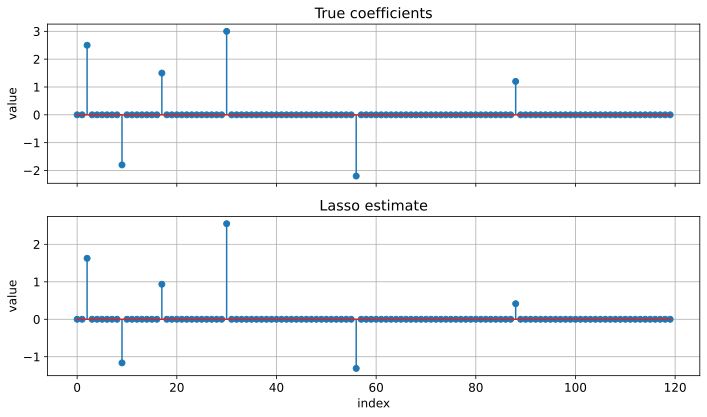

In [9]:
# Lasso example
rng = np.random.default_rng(4)

m_lasso, n_lasso = 80, 120
X_lasso = rng.standard_normal((m_lasso, n_lasso))

beta_true = np.zeros(n_lasso)
support_true = np.array([2, 9, 17, 30, 56, 88])
beta_true[support_true] = np.array([2.5, -1.8, 1.5, 3.0, -2.2, 1.2])

y_lasso = X_lasso @ beta_true + 0.15 * rng.standard_normal(m_lasso)

beta = cp.Variable(n_lasso)
tau = 8.0

lasso_problem = cp.Problem(
    cp.Minimize(0.5 * cp.sum_squares(X_lasso @ beta - y_lasso)),
    [cp.norm(beta, 1) <= tau],
)
solve_or_raise(lasso_problem, solver=cp.OSQP, warm_start=True)

beta_hat = beta.value
support_est = np.where(np.abs(beta_hat) > 1e-2)[0]

print("Objective value:", np.round(lasso_problem.value, 6))
print("True support:", support_true.tolist())
print("Estimated support (|beta_i| > 1e-2):", support_est.tolist())
print("L1 reconstruction error:", np.round(np.linalg.norm(beta_hat - beta_true, 1), 4))

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].stem(beta_true)
axes[0].set_title("True coefficients")
axes[0].set_ylabel("value")

axes[1].stem(beta_hat)
axes[1].set_title("Lasso estimate")
axes[1].set_xlabel("index")
axes[1].set_ylabel("value")

plt.tight_layout()
plt.show()


### 3-2. Max-margin SVM

convex optimization과 geometry가 만나는 예시

linearly separable data에 대해 SVM은

$
\min_{w,b} \frac{1}{2}\|w\|_2^2
\quad \text{subject to} \quad
y_i(w^\top x_i + b) \ge 1
$

을 풉니다.

이 문제의 핵심 해석은 다음과 같습니다.

- 제약은 “모든 점이 올바른 쪽에 있고 margin 밖에 있으라”는 뜻
- 목적함수는 $\|w\|_2$를 줄여서 margin을 키우는 역할
- 따라서 해는 **가장 넓은 margin을 주는 separating hyperplane**이다


Optimal margin width ~ 2.0563
Number of support vectors: 3
Support vector indices: [7, 18, 29]


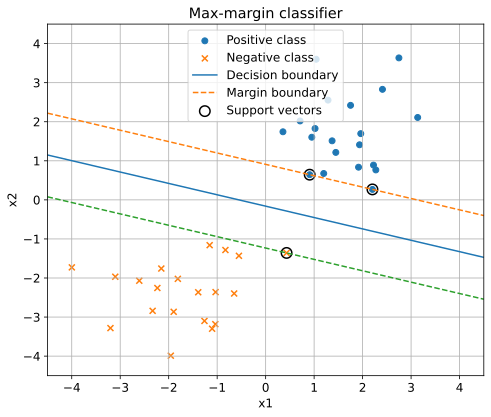

In [11]:
# Hard-margin SVM
rng = np.random.default_rng(5)

X_pos = rng.standard_normal((20, 2)) + np.array([2.0, 2.0])
X_neg = rng.standard_normal((20, 2)) + np.array([-2.0, -2.0])
X_svm = np.vstack([X_pos, X_neg])
y_svm = np.hstack([np.ones(X_pos.shape[0]), -np.ones(X_neg.shape[0])])

w = cp.Variable(2)
b = cp.Variable()

svm_problem = cp.Problem(
    cp.Minimize(0.5 * cp.sum_squares(w)),
    [cp.multiply(y_svm, X_svm @ w + b) >= 1],
)
solve_or_raise(svm_problem, solver=cp.OSQP, warm_start=True)

w_hat = w.value
b_hat = b.value
margins = y_svm * (X_svm @ w_hat + b_hat)
support_vectors = np.where(np.abs(margins - 1.0) < 1e-3)[0]

print("Optimal margin width ~", np.round(2.0 / np.linalg.norm(w_hat), 4))
print("Number of support vectors:", len(support_vectors))
print("Support vector indices:", support_vectors.tolist())

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_pos[:, 0], X_pos[:, 1], label="Positive class")
ax.scatter(X_neg[:, 0], X_neg[:, 1], marker="x", label="Negative class")

xs, decision, plus, minus = margin_lines(w_hat, b_hat, (-4.5, 4.5))
ax.plot(xs, decision, label="Decision boundary")
ax.plot(xs, plus, linestyle="--", label="Margin boundary")
ax.plot(xs, minus, linestyle="--")

ax.scatter(
    X_svm[support_vectors, 0],
    X_svm[support_vectors, 1],
    s=110,
    facecolors="none",
    edgecolors="k",
    linewidths=1.5,
    label="Support vectors",
)

ax.set_title("Max-margin classifier")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_xlim(-4.5, 4.5)
ax.set_ylim(-4.5, 4.5)
ax.legend(loc="best")
plt.tight_layout()
plt.show()


Lasso와 SVM은 서로 다른 응용처럼 보이지만 구조적으로 닮아 있습니다.

- 둘 다 convex하다
- 둘 다 norm이 중요한 역할을 한다
- 둘 다 해석 가능한 geometry가 있다
- 둘 다 regularization / margin / support라는 말을 낳는다

### 질문
1. 왜 $\ell_2$ 대신 $\ell_1$ 제약이 sparsity를 더 잘 유도할까?
2. SVM에서 support vector가 아닌 점들은 왜 해를 거의 결정하지 않는가?
3. soft-margin SVM으로 가면 어떤 변수가 추가될까?


## Part 4. Portfolio optimization 

- convex optimization의 대표 응용인 **Markowitz portfolio optimization**

### 핵심 수학
자산 수익률의 평균을 $\mu$, 공분산을 $\Sigma$, portfolio weight를 $w$라 하면

$
\mu^\top w
$

는 기대수익률,

$
w^\top \Sigma w
$

는 분산 기반 risk입니다.

고전적 Markowitz 문제는

$
\max_w \; \mu^\top w - \gamma w^\top \Sigma w
\quad \text{subject to} \quad
\mathbf{1}^\top w = 1,\; w \in \mathcal{W}
$

입니다.

여기서 $\gamma > 0$는 risk aversion parameter입니다.  
$\gamma$를 바꾸면 **efficient frontier**가 그려집니다.


### 4-1. Long-only efficient frontier

먼저 가장 기본적인 long-only portfolio부터 시작합니다.  
즉,

$
w \ge 0,\qquad \mathbf{1}^\top w = 1
$

입니다.

이 경우 해석은 비교적 단순합니다.

- 작은 $\gamma$: 공격적, return 중심
- 큰 $\gamma$: 보수적, risk 중심
- frontier의 각 점은 “그 위험 수준에서 더 좋게 만들 수 없는” Pareto-optimal portfolio


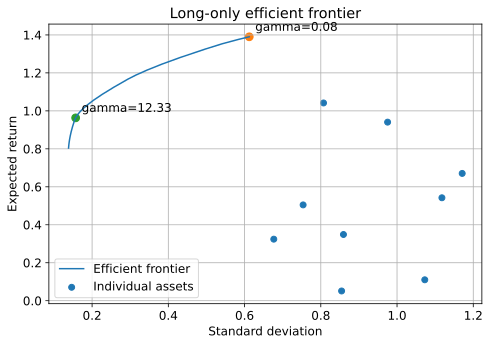

In [12]:
# Markowitz frontier (long-only)
rng = np.random.default_rng(7)

n_assets = 10
mu = np.abs(rng.standard_normal(n_assets)) + 0.05
Sigma_raw = rng.standard_normal((n_assets, n_assets))
Sigma = Sigma_raw.T @ Sigma_raw / n_assets

w = cp.Variable(n_assets)
gamma = cp.Parameter(nonneg=True)

ret = mu @ w
risk = cp.quad_form(w, Sigma)

portfolio_problem = cp.Problem(
    cp.Maximize(ret - gamma * risk),
    [cp.sum(w) == 1, w >= 0],
)

gamma_vals = np.logspace(-2, 2, 45)
risk_data = np.zeros_like(gamma_vals)
ret_data = np.zeros_like(gamma_vals)

for i, gamma_val in enumerate(gamma_vals):
    gamma.value = gamma_val
    solve_or_raise(portfolio_problem, solver=cp.OSQP, warm_start=True)
    risk_data[i] = np.sqrt(risk.value)
    ret_data[i] = ret.value

markers = [10, 34]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(risk_data, ret_data, label="Efficient frontier")
ax.scatter(np.sqrt(np.diag(Sigma)), mu, label="Individual assets")
for idx in markers:
    ax.scatter(risk_data[idx], ret_data[idx], s=60)
    ax.annotate(
        f"gamma={gamma_vals[idx]:.2f}",
        (risk_data[idx], ret_data[idx]),
        xytext=(6, 6),
        textcoords="offset points",
    )
ax.set_title("Long-only efficient frontier")
ax.set_xlabel("Standard deviation")
ax.set_ylabel("Expected return")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


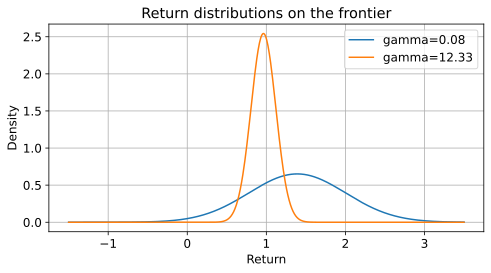

In [13]:
# Return distributions at two points on the frontier
x_plot = np.linspace(-1.5, 3.5, 600)

fig, ax = plt.subplots(figsize=(7, 4))
for idx in markers:
    gamma.value = gamma_vals[idx]
    solve_or_raise(portfolio_problem, solver=cp.OSQP, warm_start=True)
    mean_val = ret.value
    var_val = risk.value
    ax.plot(x_plot, gaussian_pdf(x_plot, mean_val, var_val), label=f"gamma={gamma.value:.2f}")

ax.set_title("Return distributions on the frontier")
ax.set_xlabel("Return")
ax.set_ylabel("Density")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


### 4-2. Leverage limit

중요한 확장은

$
\|w\|_1 \le L^{\max}
$

입니다.  
이 제약은 long-only를 넘어 short position을 허용하되, 전체 leverage는 제한하겠다는 뜻입니다.

직관적으로,

- $L^{\max}=1$: long-only에 가깝다
- $L^{\max}>1$: shorting과 leverage를 허용한다
- frontier가 바깥으로 확장되면서 더 큰 return과 risk가 가능해진다


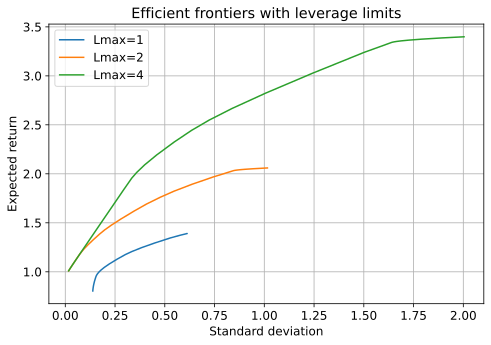

In [14]:
# Efficient frontiers under leverage limits
Lmax = cp.Parameter(nonneg=True)
portfolio_leverage_problem = cp.Problem(
    cp.Maximize(ret - gamma * risk),
    [cp.sum(w) == 1, cp.norm(w, 1) <= Lmax],
)

L_values = [1.0, 2.0, 4.0]
gamma_vals_lev = np.logspace(-2, 2, 35)

fig, ax = plt.subplots(figsize=(7, 5))
for L_val in L_values:
    risks = []
    returns = []
    for gamma_val in gamma_vals_lev:
        Lmax.value = L_val
        gamma.value = gamma_val
        solve_or_raise(portfolio_leverage_problem, solver=cp.OSQP, warm_start=True)
        risks.append(np.sqrt(risk.value))
        returns.append(ret.value)
    ax.plot(risks, returns, label=f"Lmax={L_val:g}")

ax.set_title("Efficient frontiers with leverage limits")
ax.set_xlabel("Standard deviation")
ax.set_ylabel("Expected return")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


### 4-3. Factor covariance model

실제 자산 수가 커지면 $\Sigma \in \mathbb{R}^{n\times n}$ 전체를 다루는 것이 부담스러워집니다.  
이때 자주 쓰는 모델이

$
\Sigma = F \widetilde{\Sigma} F^\top + D
$

형태의 factor model입니다.

- $F$: factor loading matrix
- $\widetilde{\Sigma}$: factor covariance
- $D$: idiosyncratic risk (대각 성분)

이 모델의 장점은, 자산 수 $n$은 커도 factor 수 $k$는 훨씬 작을 수 있어서 계산이 빨라진다는 점입니다.


In [15]:
# Factor model vs full covariance model
rng = np.random.default_rng(8)

n_big = 200
k_factor = 10

mu_big = np.abs(rng.standard_normal(n_big)) + 0.02
F = rng.standard_normal((n_big, k_factor)) / np.sqrt(k_factor)

tmp = rng.standard_normal((k_factor, k_factor))
Sigma_tilde = tmp.T @ tmp / k_factor
d_diag = rng.uniform(0.05, 0.2, size=n_big)

Sigma_full = F @ Sigma_tilde @ F.T + np.diag(d_diag)

gamma_fixed = 0.2
Lmax_fixed = 2.0

w_full = cp.Variable(n_big)
full_problem = cp.Problem(
    cp.Maximize(mu_big @ w_full - gamma_fixed * cp.quad_form(w_full, Sigma_full)),
    [cp.sum(w_full) == 1, cp.norm(w_full, 1) <= Lmax_fixed],
)

t0 = time.perf_counter()
solve_or_raise(full_problem, solver=cp.OSQP, warm_start=True)
t1 = time.perf_counter()

w_factor = cp.Variable(n_big)
f_factor = cp.Variable(k_factor)
risk_factor_expr = cp.quad_form(f_factor, Sigma_tilde) + cp.sum(cp.multiply(d_diag, cp.square(w_factor)))
factor_problem = cp.Problem(
    cp.Maximize(mu_big @ w_factor - gamma_fixed * risk_factor_expr),
    [cp.sum(w_factor) == 1, cp.norm(w_factor, 1) <= Lmax_fixed, f_factor == F.T @ w_factor],
)

t2 = time.perf_counter()
solve_or_raise(factor_problem, solver=cp.OSQP, warm_start=True)
t3 = time.perf_counter()

comparison = pd.DataFrame(
    [
        {
            "model": "full covariance",
            "objective": full_problem.value,
            "wall_time_sec": t1 - t0,
        },
        {
            "model": "factor covariance",
            "objective": factor_problem.value,
            "wall_time_sec": t3 - t2,
        },
    ]
)

print(comparison)
print()
print("Weight difference norm:", np.linalg.norm(w_full.value - w_factor.value))
comparison


               model  objective  wall_time_sec
0    full covariance   4.241046       0.054182
1  factor covariance   4.241046       0.014813

Weight difference norm: 6.557897197977637e-16


,model,objective,wall_time_sec
0,full covariance,4.241046,0.054182
1,factor covariance,4.241046,0.014813



- factor model은 **근사 모델**이 아니라, 우리가 만든 $\Sigma$를 정확히 분해해서 다시 쓴 것입니다.
- 그래서 objective 값과 해가 사실상 일치합니다.
- 하지만 변수/연산 구조가 달라지면서 계산량이 눈에 띄게 줄어듭니다.

### 질문
1. efficient frontier는 왜 “trade-off curve”라고 부를 수 있는가?
2. leverage가 커지면 왜 frontier가 바깥으로 이동하는가?
3. factor model이 클수록 좋은가? factor 수를 너무 많이 잡으면 무슨 일이 생길까?


## Part 5. SOCP와 robust optimization

**norm 제약**이 핵심인 문제들

### 왜 SOCP가 중요한가?
다음과 같은 제약은 아주 자주 등장합니다.

$
\|Ax+b\|_2 \le c^\top x + d
$

이것은 second-order cone 제약입니다.  
Euclidean distance, uncertainty radius, worst-case perturbation이 모두 이 구조로 들어옵니다.

오늘의 두 예제는

1. **smallest enclosing circle**
2. **robust LP의 SOCP counterpart**

입니다.


### 5-1. Smallest enclosing circle

점들 $p_i\in\mathbb{R}^2$를 모두 포함하는 가장 작은 원을 찾고 싶다고 합시다.  
중심을 $c$, 반지름을 $r$라고 하면

$
\min_{c,r} r
\quad \text{subject to} \quad
\|p_i-c\|_2 \le r,\;\; r\ge 0
$

입니다.

이 식은 SOCP의 전형적인 예입니다.  
또한 DCP 관점에서도 `cp.norm(point - center, 2) <= r`가 **가장 자연스러운 표기**입니다.


Center: [2.3625 2.325 ]
Radius: 1.9254


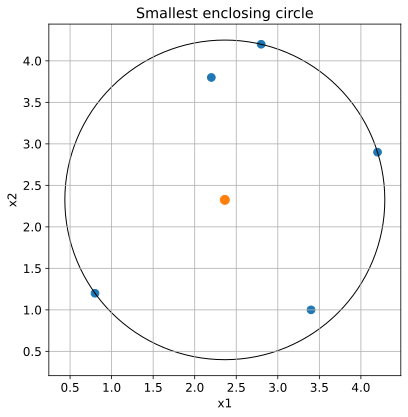

In [16]:
# Smallest enclosing circle
points = np.array(
    [
        [0.8, 1.2],
        [2.2, 3.8],
        [3.4, 1.0],
        [4.2, 2.9],
        [2.8, 4.2],
    ]
)

center_circle = cp.Variable(2)
radius_circle = cp.Variable(nonneg=True)

circle_problem = cp.Problem(
    cp.Minimize(radius_circle),
    [cp.norm(points[i] - center_circle, 2) <= radius_circle for i in range(points.shape[0])],
)
solve_or_raise(circle_problem, solver=cp.CLARABEL)

print("Center:", np.round(center_circle.value, 4))
print("Radius:", np.round(radius_circle.value, 4))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(points[:, 0], points[:, 1], s=60)
ax.add_patch(Circle(center_circle.value, radius_circle.value, fill=False))
ax.scatter(center_circle.value[0], center_circle.value[1], s=80)
ax.set_title("Smallest enclosing circle")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


### 5-2. Robust LP: uncertainty가 norm으로 바뀌는 순간

이제 불확실성이 있는 선형 제약을 생각해봅시다.

$
(a_1 + u)^\top x \le b_1 \quad \text{for all } \|u\|_2 \le \rho
$

같은 제약은 “최악의 \(u\)”를 고려해야 하므로 단순 LP가 아닙니다.

하지만 worst-case를 계산하면

$
a_1^\top x + \rho \|x\|_2 \le b_1
$

가 됩니다.  
즉, **uncertainty set의 support function**이 norm으로 나타납니다.

이것이 robust optimization과 cone programming이 자연스럽게 연결되는 이유입니다.


Robust optimal x: [0.5676 1.3982]
Robust optimal objective: 2.5251


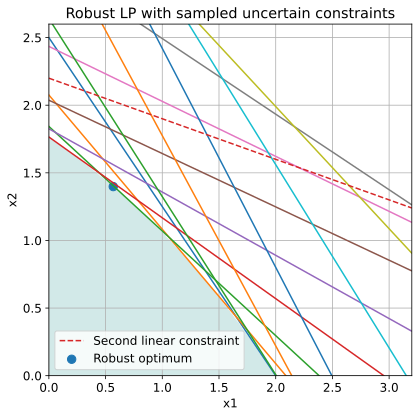

In [17]:
# Robust LP as an SOCP
a_bar = np.array([1.0, 1.2])
rho = 0.5
b1 = 3.0

a2 = np.array([0.3, 1.0])
b2 = 2.2

c = np.array([1.0, 1.4])

x_robust = cp.Variable(2, nonneg=True)

robust_problem = cp.Problem(
    cp.Maximize(c @ x_robust),
    [
        a_bar @ x_robust + rho * cp.norm(x_robust, 2) <= b1,
        a2 @ x_robust <= b2,
    ],
)
solve_or_raise(robust_problem, solver=cp.CLARABEL)

print("Robust optimal x:", np.round(x_robust.value, 4))
print("Robust optimal objective:", np.round(robust_problem.value, 4))

X, Y = make_grid((0.0, 3.2), (0.0, 2.6), n=450)
robust_mask = (
    (a_bar[0] * X + a_bar[1] * Y + rho * np.sqrt(X**2 + Y**2) <= b1 + 1e-9)
    & (a2[0] * X + a2[1] * Y <= b2 + 1e-9)
)

theta = np.linspace(0, 2 * np.pi, 50)
sampled_directions = np.c_[np.cos(theta), np.sin(theta)]

fig, ax = plt.subplots(figsize=(6, 6))
ax.contourf(X, Y, robust_mask.astype(float), levels=[0.5, 1.5], alpha=0.2)

for u in sampled_directions[::4]:
    a = a_bar + rho * u
    plot_line(ax, a, b1, (0.0, 3.2), linestyle="-")

plot_line(ax, a2, b2, (0.0, 3.2), label="Second linear constraint", linestyle="--")
ax.scatter(x_robust.value[0], x_robust.value[1], s=70, label="Robust optimum")

ax.set_title("Robust LP with sampled uncertain constraints")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_xlim(0.0, 3.2)
ax.set_ylim(0.0, 2.6)
ax.legend(loc="best")
plt.tight_layout()
plt.show()


샘플링한 주황색 직선들은 “불확실성이 허용하는 여러 constraint line”을 보여줍니다.  
robust 해는 그 모든 경우를 동시에 만족하도록 선택됩니다.

### 질문
1. uncertainty set이 $\ell_\infty$ ball이면 robust counterpart는 어떤 norm을 낳을까?
2. smallest enclosing circle를 higher dimension으로 올리면 무엇이 바뀌고 무엇은 그대로일까?
3. robust optimization은 왜 종종 “보수적이지만 안전한 설계”로 해석되는가?


## Part 6. SDP와 optimality geometry 

이번 파트에서는 두 가지를 묶어서 봅니다.

1. **semidefinite programming (SDP)**: 행렬 변수를 쓰는 convex optimization  
2. **optimality condition의 기하학**: gradient와 active constraint가 어떻게 만나는가  

이 둘은 겉보기에 멀어 보이지만, 둘 다 “convex structure가 해를 강하게 통제한다”는 같은 메시지를 줍니다.


### 6-1. Leading eigenvector의 SDP relaxation

대칭행렬 \(A\)의 leading eigenvector를 찾는 원래 문제는

$
\max_{\|x\|_2=1} x^\top A x
$

입니다.

rank-one 행렬 $X = xx^\top$를 생각하면

$
x^\top A x = \mathrm{tr}(AX), \qquad X \succeq 0,\qquad \mathrm{tr}(X)=1
$

이므로 SDP relaxation
$
\max_X \mathrm{tr}(AX)
\quad \text{subject to} \quad
X \succeq 0,\; \mathrm{tr}(X)=1
$

을 얻게 됩니다.

대칭행렬 $A$에 대해서는 이 relaxation이 사실상 정확하게 leading eigenspace를 회복합니다.


In [18]:
# SDP for leading eigenvector
A_sdp = np.array([[2.0, 1.0], [1.0, 6.0]])

X_sdp = cp.Variable((2, 2), symmetric=True)
sdp_problem = cp.Problem(
    cp.Maximize(cp.trace(A_sdp @ X_sdp)),
    [X_sdp >> 0, cp.trace(X_sdp) == 1],
)
solve_or_raise(sdp_problem, solver=cp.SCS, eps=1e-6, warm_start=True)

eigvals, eigvecs = np.linalg.eigh(A_sdp)
leading_vec = eigvecs[:, -1]
leading_outer = np.outer(leading_vec, leading_vec)

print("SDP solution X:")
print(np.round(X_sdp.value, 6))
print()
print("Leading eigenvalue from SDP objective:", np.round(sdp_problem.value, 6))
print("Leading eigenvalue from numpy:", np.round(eigvals[-1], 6))
print()
print("Rank-one matrix from numpy eigenvector:")
print(np.round(leading_outer, 6))


SDP solution X:
[[0.0528 0.2236]
 [0.2236 0.9472]]

Leading eigenvalue from SDP objective: 6.236068
Leading eigenvalue from numpy: 6.236068

Rank-one matrix from numpy eigenvector:
[[0.0528 0.2236]
 [0.2236 0.9472]]


### 6-2. Optimality condition의 geometry

이제 아주 중요한 그림을 다시 봅시다.  
convex objective $f$를 convex feasible set 위에서 최소화할 때, 최적점 $x^\star$에서는

$
\nabla f(x^\star)^\top (y - x^\star) \ge 0
\quad \text{for all feasible } y
$

가 성립합니다.

즉, **negative gradient는 feasible direction으로 더 내려갈 수 없다는 사실**을 말합니다.  
경계점에서는 이것이 normal cone, KKT multiplier, supporting hyperplane과 연결됩니다.


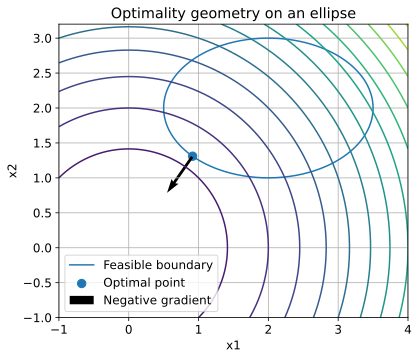

Optimal point: [0.9148 1.3096]
Dual multiplier for active constraint: 1.896906


In [19]:
# Geometry of first-order optimality
x1 = cp.Variable()
x2 = cp.Variable()

a_center, b_center = 2.0, 2.0
rx, ry = 1.5, 1.0

ellipse_constraint = ((x1 - a_center) / rx) ** 2 + ((x2 - b_center) / ry) ** 2 <= 1
optimality_problem = cp.Problem(
    cp.Minimize(cp.square(x1) + cp.square(x2)),
    [ellipse_constraint],
)
solve_or_raise(optimality_problem, solver=cp.CLARABEL)

x_opt = np.array([x1.value, x2.value])
dual_val = optimality_problem.constraints[0].dual_value

X, Y = make_grid((-1.0, 4.0), (-1.0, 3.2), n=400)
Z = X**2 + Y**2
theta = np.linspace(0, 2 * np.pi, 400)
ellipse_x = a_center + rx * np.cos(theta)
ellipse_y = b_center + ry * np.sin(theta)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(ellipse_x, ellipse_y, label="Feasible boundary")
ax.contour(X, Y, Z, levels=15)
ax.scatter(x_opt[0], x_opt[1], s=70, label="Optimal point")

grad = 2 * x_opt
ax.quiver(
    x_opt[0],
    x_opt[1],
    -0.2 * grad[0],
    -0.2 * grad[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.008,
    label="Negative gradient",
)

ax.set_title("Optimality geometry on an ellipse")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_xlim(-1.0, 4.0)
ax.set_ylim(-1.0, 3.2)
ax.set_aspect("equal")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

print("Optimal point:", np.round(x_opt, 4))
print("Dual multiplier for active constraint:", np.round(dual_val, 6))


여기서 dual multiplier가 양수로 나오는 것은, 해당 제약이 실제로 최적점에서 **active** 하다는 뜻입니다.  
즉, gradient만으로는 더 내려가고 싶지만 제약 경계가 그 방향을 막고 있다는 뜻입니다.

### 질문
1. 왜 PSD constraint $X \succeq 0$는 convex constraint인가?
2. optimality condition을 supporting hyperplane 언어로 어떻게 다시 말할 수 있을까?
3. active constraint의 dual variable이 0이 아닐 때 어떤 해석이 가능한가?


## Part 7. Finite-horizon optimal control via convex optimization

제어 문제를 convex optimization으로 쓰는 방법

### 문제 설정
선형 시불변 시스템

$
x_{t+1} = A x_t + B u_t,\qquad t=0,\dots,T-1
$

에서

- state $x_t$를 원점으로 보내고 싶고
- control effort $u_t$도 너무 크지 않게 하고
- actuator saturation $\|u_t\|_\infty \le 1$도 만족해야 한다

고 합시다.

그러면

$
\min \sum_{t=0}^{T-1} \left(\|x_t\|_2^2 + \|u_t\|_2^2\right)
$

subject to

$
x_{t+1}=Ax_t+Bu_t,\qquad
\|u_t\|_\infty \le 1,\qquad
x_T=0
$

라는 convex QP가 됩니다.


이 문제에서 중요한 것은 **시간축 전체가 하나의 optimization variable 묶음**이라는 점입니다.

- $x \in \mathbb{R}^{n\times (T+1)}$
- $u \in \mathbb{R}^{m\times T}$

를 한 번에 두고, dynamics를 연결 제약으로 넣습니다.  
즉, “한 시점씩 제어한다”가 아니라 **trajectory 전체를 한 번에 설계**하는 것입니다.


In [20]:
# Finite-horizon control problem
rng = np.random.default_rng(9)

n_state = 8
m_input = 2
T_horizon = 40
alpha = 0.2
beta_scale = 3.0

A_ctrl = np.eye(n_state) - alpha * rng.random((n_state, n_state))
B_ctrl = rng.standard_normal((n_state, m_input))
x0_ctrl = beta_scale * rng.standard_normal(n_state)

x_ctrl = cp.Variable((n_state, T_horizon + 1))
u_ctrl = cp.Variable((m_input, T_horizon))

cost = 0
constraints = [x_ctrl[:, 0] == x0_ctrl]
for t in range(T_horizon):
    cost += cp.sum_squares(x_ctrl[:, t]) + cp.sum_squares(u_ctrl[:, t])
    constraints += [x_ctrl[:, t + 1] == A_ctrl @ x_ctrl[:, t] + B_ctrl @ u_ctrl[:, t]]
    constraints += [cp.norm(u_ctrl[:, t], "inf") <= 1]
constraints += [x_ctrl[:, T_horizon] == 0]

control_problem = cp.Problem(cp.Minimize(cost), constraints)
solve_or_raise(control_problem, solver=cp.OSQP, warm_start=True)

print("Optimal control cost:", np.round(control_problem.value, 4))
print("Terminal state norm:", np.round(np.linalg.norm(x_ctrl[:, -1].value), 8))
print("Max absolute input:", np.round(np.max(np.abs(u_ctrl.value)), 6))


Optimal control cost: 2697.1231
Terminal state norm: 0.0
Max absolute input: 1.000025


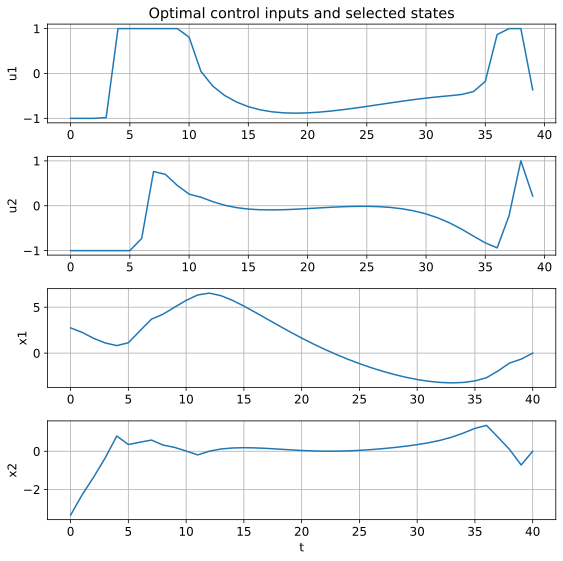

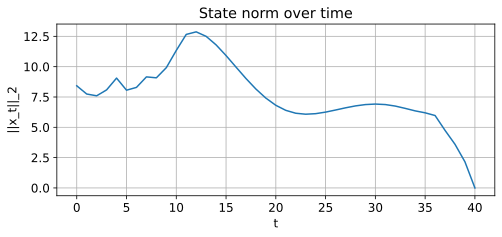

In [21]:
# Plot selected inputs and states
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(4, 1, 1)
ax.plot(u_ctrl.value[0, :])
ax.set_ylabel("u1")
ax.set_title("Optimal control inputs and selected states")

ax = fig.add_subplot(4, 1, 2)
ax.plot(u_ctrl.value[1, :])
ax.set_ylabel("u2")

ax = fig.add_subplot(4, 1, 3)
ax.plot(x_ctrl.value[0, :])
ax.set_ylabel("x1")

ax = fig.add_subplot(4, 1, 4)
ax.plot(x_ctrl.value[1, :])
ax.set_ylabel("x2")
ax.set_xlabel("t")

plt.tight_layout()
plt.show()

state_norm = np.linalg.norm(x_ctrl.value, axis=0)
plt.figure(figsize=(7, 3.5))
plt.plot(state_norm)
plt.title("State norm over time")
plt.xlabel("t")
plt.ylabel("||x_t||_2")
plt.tight_layout()
plt.show()


이 결과에서 눈여겨볼 점은 다음입니다.

- 초반에는 입력이 saturation에 붙기 쉽다
- 상태가 줄어들수록 입력도 부드러워진다
- dynamics가 선형이고 비용이 quadratic이므로 전체 문제는 QP로 유지된다

### 질문
1. terminal constraint $x_T=0$를 빼고 terminal cost만 넣으면 어떻게 달라질까?
2. input constraint가 $\|u_t\|_2 \le 1$로 바뀌면 문제 클래스는 그대로일까?
3. MPC(model predictive control)와 이 finite-horizon formulation은 어떻게 이어질까?


## Part 8. Logistic regression, regularization path

convex optimization이 통계 학습으로 어떻게 연결되는지 살펴보기.

logistic regression의 negative log-likelihood는 convex이고,  
$\ell_1$-regularization을 붙이면 sparse classification model을 만들 수 있습니다.

원본 `cvxpy_logistic_regression.ipynb`의 핵심 아이디어는 세 가지입니다.

1. logistic loss는 convex하다
2. $\ell_1$ penalty는 sparsity를 유도한다
3. $\lambda$를 바꾸면 bias-variance trade-off가 드러난다


### 8-1. 수학적 형태

데이터 $(x_i, y_i)$에서 $y_i \in \{0,1\}$라고 할 때,

$
\Pr(Y=1\mid X=x)=\sigma(\beta^\top x)
$

이며,

$
\sigma(z)=\frac{1}{1+e^{-z}}
$

입니다.

regularized logistic regression의 한 형태는

$
\max_\beta
\frac{1}{m}\sum_{i=1}^m
\left[
y_i \beta^\top x_i - \log(1+\exp(\beta^\top x_i))
\right]
- \lambda \|\beta\|_1
$

입니다.

CVXPY에서는 \(\log(1+\exp(z))\)를 직접 쓰기보다 `cp.logistic(z)` atom을 사용하는 것이 좋습니다.


In [22]:
# Logistic regression as convex optimization
rng = np.random.default_rng(10)

n_feat = 40
m_train = 80
m_test = 160

beta_true_logit = np.zeros(n_feat)
beta_true_logit[[0, 1, 4, 9, 15]] = np.array([1.2, -1.0, 0.7, 1.5, -0.8])

X_train = rng.standard_normal((m_train, n_feat))
latent_train = X_train @ beta_true_logit + 0.6 * rng.standard_normal(m_train)
p_train = 1 / (1 + np.exp(-latent_train))
y_train = (rng.random(m_train) < p_train).astype(float)

X_test = rng.standard_normal((m_test, n_feat))
latent_test = X_test @ beta_true_logit + 0.6 * rng.standard_normal(m_test)
p_test = 1 / (1 + np.exp(-latent_test))
y_test = (rng.random(m_test) < p_test).astype(float)

beta_logit = cp.Variable(n_feat)
lam = cp.Parameter(nonneg=True)

log_likelihood = cp.sum(
    cp.multiply(y_train, X_train @ beta_logit) - cp.logistic(X_train @ beta_logit)
)
logit_problem = cp.Problem(
    cp.Maximize(log_likelihood / m_train - lam * cp.norm(beta_logit, 1))
)

print("Problem is DCP:", logit_problem.is_dcp())


Problem is DCP: True


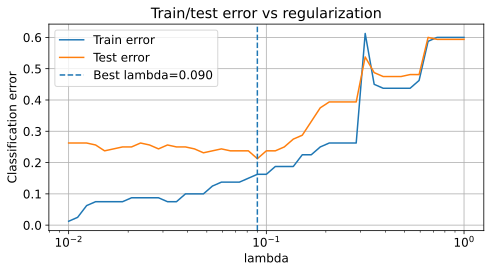

Best lambda: 0.090063
Best test error: 0.2125


In [23]:
def classification_error(scores, labels):
    preds = (scores >= 0).astype(float)
    return np.mean(preds != labels)

lambda_vals = np.logspace(-2, 0, 45)
train_error = np.zeros_like(lambda_vals)
test_error = np.zeros_like(lambda_vals)
beta_path = []

for i, lambda_val in enumerate(lambda_vals):
    lam.value = lambda_val
    solve_or_raise(logit_problem, solver=cp.SCS, warm_start=True, eps=1e-4, verbose=False)
    beta_now = beta_logit.value.copy()
    beta_path.append(beta_now)
    train_error[i] = classification_error((X_train @ beta_now), y_train)
    test_error[i] = classification_error((X_test @ beta_now), y_test)

best_idx = int(np.argmin(test_error))
best_lambda = lambda_vals[best_idx]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lambda_vals, train_error, label="Train error")
ax.plot(lambda_vals, test_error, label="Test error")
ax.axvline(best_lambda, linestyle="--", label=f"Best lambda={best_lambda:.3f}")
ax.set_xscale("log")
ax.set_title("Train/test error vs regularization")
ax.set_xlabel("lambda")
ax.set_ylabel("Classification error")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

print("Best lambda:", np.round(best_lambda, 6))
print("Best test error:", np.round(test_error[best_idx], 4))


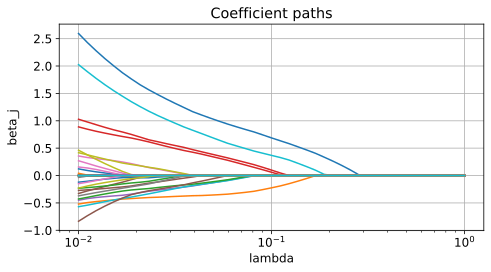

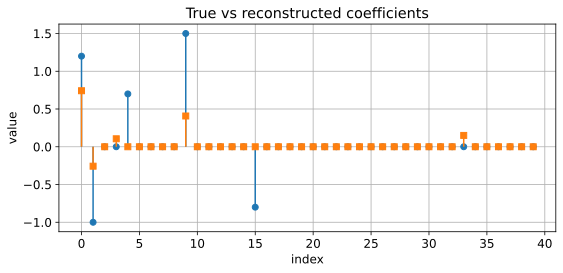

Selected support at best lambda: [0, 1, 3, 9, 33]


In [24]:
# Coefficient path and reconstruction
fig, ax = plt.subplots(figsize=(7, 4))
for j in range(n_feat):
    ax.plot(lambda_vals, [beta_path[i][j] for i in range(len(lambda_vals))])
ax.set_xscale("log")
ax.set_title("Coefficient paths")
ax.set_xlabel("lambda")
ax.set_ylabel("beta_j")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.stem(beta_true_logit, linefmt="C0-", markerfmt="C0o", basefmt=" ")
ax.stem(beta_path[best_idx], linefmt="C1-", markerfmt="C1s", basefmt=" ")
ax.set_title("True vs reconstructed coefficients")
ax.set_xlabel("index")
ax.set_ylabel("value")
plt.tight_layout()
plt.show()

selected_support = np.where(np.abs(beta_path[best_idx]) > 1e-2)[0]
print("Selected support at best lambda:", selected_support.tolist())


### 정리: 예제는 달라도 구조는 반복된다

지금까지 본 예제들을 다시 보면, 사실 같은 패턴이 계속 등장합니다.

- **LP**: affine objective + affine constraints
- **QP**: quadratic objective + affine constraints
- **SOCP**: norm constraints
- **SDP**: PSD matrix constraints
- **logistic model**: exponential-family convex atom + \(\ell_1\) regularization

즉, 응용은 달라도 “어떤 형식을 어떻게 조합하느냐”가 핵심입니다.


In [25]:
summary_df = pd.DataFrame(
    [
        ["Transportation", "LP", "sum, multiply, nonneg", "Flow allocation"],
        ["Linear-fractional transform", "LP after change of variables", "affine constraints", "Homogenization trick"],
        ["Chebyshev center", "LP / SOCP flavor", "norm of row coefficients", "Largest inscribed ball"],
        ["Lasso", "Convex quadratic model", "sum_squares, norm1", "Sparse recovery"],
        ["Hard-margin SVM", "QP", "sum_squares, affine inequalities", "Maximum margin"],
        ["Portfolio optimization", "QP", "quad_form, norm1", "Risk-return trade-off"],
        ["Smallest enclosing circle", "SOCP", "norm", "Distance geometry"],
        ["Robust LP", "SOCP", "norm as support function", "Worst-case protection"],
        ["Leading eigenvector relaxation", "SDP", "symmetric matrix, PSD cone", "Spectral optimization"],
        ["Finite-horizon control", "QP", "sum_squares, linear dynamics", "Trajectory design"],
        ["Logistic regression", "Exponential-cone model", "logistic, norm1", "Classification + sparsity"],
    ],
    columns=["Example", "Class", "Key atoms", "Interpretation"],
)
summary_df


,Example,Class,Key atoms,Interpretation
0,Transportation,LP,"sum, multiply, nonneg",Flow allocation
1,Linear-fractional transform,LP after change of variables,affine constraints,Homogenization trick
2,Chebyshev center,LP / SOCP flavor,norm of row coefficients,Largest inscribed ball
3,Lasso,Convex quadratic model,"sum_squares, norm1",Sparse recovery
4,Hard-margin SVM,QP,"sum_squares, affine inequalities",Maximum margin
5,Portfolio optimization,QP,"quad_form, norm1",Risk-return trade-off
6,Smallest enclosing circle,SOCP,norm,Distance geometry
7,Robust LP,SOCP,norm as support function,Worst-case protection
8,Leading eigenvector relaxation,SDP,"symmetric matrix, PSD cone",Spectral optimization
9,Finite-horizon control,QP,"sum_squares, linear dynamics",Trajectory design
